In [1]:
import pandas as pd

df= pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv')
df2= pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_master_customer_data_enmascarado_completa.csv')
extracted_df = df[['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado','var_rpta_alt','fecha_var_rpta_alt']]


c:\Users\daniealv\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (28,37,38) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
c:\Users\daniealv\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (17,18,19,30,31) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [11]:
tipos=df2.dtypes


In [21]:
# Convertir las columnas a tipo numérico
columns_to_convert = ['total_ing', 'num_hijos', 'tot_patrimonio', 'tot_activos', 'tot_pasivos','personas_dependientes','edad_cli']
df2[columns_to_convert] = df2[columns_to_convert].apply(pd.to_numeric, errors='coerce')

# Convertir las columnas a tipo entero
df2[columns_to_convert] = df2[columns_to_convert].astype('Int64')

# Verificar la conversión
print(df2[columns_to_convert].dtypes)

total_ing                Int64
num_hijos                Int64
tot_patrimonio           Int64
tot_activos              Int64
tot_pasivos              Int64
personas_dependientes    Int64
edad_cli                 Int64
dtype: object


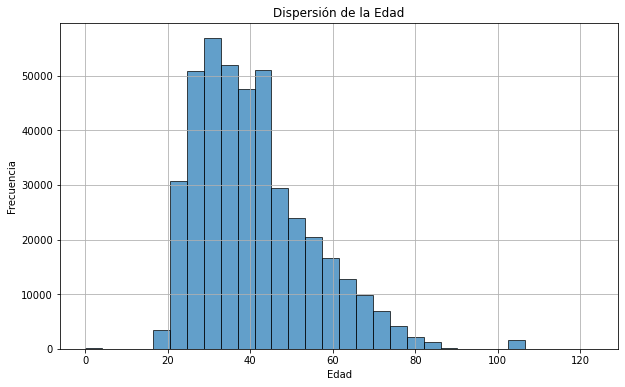

In [24]:
import matplotlib.pyplot as plt

# Crear un histograma de la columna 'edad_cli'
plt.figure(figsize=(10, 6))
plt.hist(df2['edad_cli'].dropna(), bins=30, edgecolor='k', alpha=0.7)
plt.title('Dispersión de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [23]:
missing_values = df2.isnull().sum()
print(missing_values)

nit_enmascarado             0
cod_tipo_doc                0
tipo_cli                    0
ctrl_terc                   0
genero_cli                  0
ano_nac_cli                 0
edad_cli                 7942
estado_civil                0
tipo_vivienda               0
num_hijos                7942
personas_dependientes    7945
nivel_academico             0
ocup                        0
act_econom                  0
sector                      0
subsector                   0
declarante                  0
total_ing                   4
tot_activos                 4
tot_pasivos                 4
origen_fondos               0
f_vinc                      0
f_ult_mantenimiento         0
canal_actualizacion         0
cli_actualizado             0
segm                        0
subsegm                     0
nicho                       0
region_of                   0
nombre_dpto_dirp            0
egresos_mes                 0
tot_patrimonio              4
ciiu                        0
smmlv     

In [22]:

master=df2.describe(include='all')

In [ ]:
# Ensure the columns are of integer type
df2[['year', 'month', 'ingestion_day']] = df2[['year', 'month', 'ingestion_day']].astype(int)

# Handle any missing values by filling them with a default value (e.g., 1)
df2[['year', 'month', 'ingestion_day']] = df2[['year', 'month', 'ingestion_day']].fillna(1)

# Convert year, month, day to a datetime column in df2
df2['fecha'] = pd.to_datetime(df2[['year', 'month', 'ingestion_day']].rename(columns={'ingestion_day': 'day'}))

# Hacer el cruce basado en nit_enmascarado
merged_df = pd.merge(extracted_df, df2, on='nit_enmascarado',how='left')

# Calcular la diferencia de días entre fecha_var_rpta_alt y fecha
merged_df['fecha_var_rpta_alt'] = pd.to_datetime(merged_df['fecha_var_rpta_alt'], format='%Y%m')
merged_df['diff_days'] = (merged_df['fecha_var_rpta_alt'] - merged_df['fecha']).dt.days.abs()



In [26]:
# Primero, ordenamos el DataFrame por 'nit_enmascarado' y 'diff_days'
merged_df = merged_df.sort_values(by=['nit_enmascarado', 'diff_days'])

# Luego, eliminamos los duplicados, manteniendo el registro con la menor diferencia de días
merged_df = merged_df.drop_duplicates(subset=['nit_enmascarado','num_oblig_enmascarado','num_oblig_orig_enmascarado','fecha_var_rpta_alt'], keep='first')



In [27]:
merged_df = merged_df.drop(columns=['year', 'month', 'ingestion_day'])


In [48]:
# Convertir los campos a tipos de datos numéricos
fields_to_convert = ['ano_nac_cli', 'edad_cli', 'total_ing', 'tot_activos', 'tot_pasivos', 'egresos_mes', 'tot_patrimonio']
merged_df[fields_to_convert] = merged_df[fields_to_convert].apply(pd.to_numeric, errors='coerce')

# Verificar la conversión
print(merged_df[fields_to_convert].dtypes)

ano_nac_cli       float64
edad_cli          float64
total_ing         float64
tot_activos       float64
tot_pasivos       float64
egresos_mes       float64
tot_patrimonio    float64
dtype: object


var_rpta_alt                  1.000000
num_oblig_enmascarado         0.049799
nit_enmascarado               0.019771
diff_days                     0.000779
tot_pasivos                  -0.001690
tot_activos                  -0.002422
tot_patrimonio               -0.002894
num_hijos                    -0.003056
total_ing                    -0.003568
f_ult_mantenimiento          -0.004061
f_vinc                       -0.005097
personas_dependientes        -0.009163
edad_cli                     -0.022359
num_oblig_orig_enmascarado   -0.044118
cod_tipo_doc                 -0.087706
smmlv                              NaN
Name: var_rpta_alt, dtype: float64


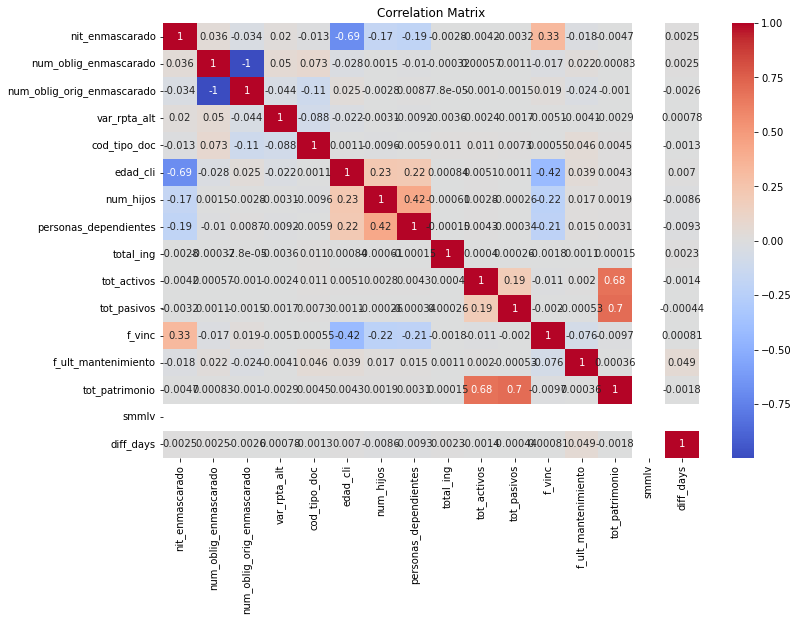

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la correlación para variables numéricas
correlation_matrix = merged_df.corr()
print(correlation_matrix['var_rpta_alt'].sort_values(ascending=False))

# Graficar la correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [50]:
categorical_vars = ['tipo_cli', 'genero_cli', 'estado_civil', 'tipo_vivienda']
for var in categorical_vars:
    table = pd.crosstab(merged_df[var], merged_df['var_rpta_alt'], margins=True)
    print(f"Relación entre var_rpta_alt y {var}")
    print(table)
    print("\n")

Relación entre var_rpta_alt y tipo_cli
var_rpta_alt           0       1     All
tipo_cli                                
PERSONA JURíDICA    9396    2391   11787
PERSONA NATURAL   227686  216817  444503
All               237082  219208  456290


Relación entre var_rpta_alt y genero_cli
var_rpta_alt       0       1     All
genero_cli                          
F             108563  104343  212906
M             119112  112469  231581
None            9407    2396   11803
All           237082  219208  456290


Relación entre var_rpta_alt y estado_civil
var_rpta_alt       0       1     All
estado_civil                        
CASADO         47721   44385   92106
DIVORCIADO      5715    5080   10795
NO INFORMA     17053   16065   33118
None           23297   11732   35029
OTRO            1103    1163    2266
SOLTERO        99247  100971  200218
UNION LIBRE    40160   37476   77636
VIUDO           2786    2336    5122
All           237082  219208  456290


Relación entre var_rpta_alt y tipo_vi